In [1]:
%cd /home/smalani/PartialObservations_URP

from URPModel import make_plots, helper, URP_metrics

/home/smalani/PartialObservations_URP


In [2]:
import numpy as np
from config import config

Cases = ["Case1", "Case2a", "Case2b", "Case3", "Case4", "Case5", "Case6","Case8a", "Case8b"]

minindex = []
for j in range(len(Cases)):
    # Case = "Case8a"
    Case = Cases[j]
    if Case == "Case8a":
        config["MODEL"]["BOX"] = 'Grey'
        config["MODEL"]["Parameters"] = 'Fixed'
        config["DATA"]["N_TRAIN"] = 77
    elif Case == "Case8b":
        config["MODEL"]["BOX"] = 'Grey'
        config["MODEL"]["Parameters"] = 'Trainable'
        config["DATA"]["N_TRAIN"] = 77
    elif Case == "Case1":
        config["MODEL"]["BOX"] = 'Black'
        config["MODEL"]["Parameters"] = 'Fixed'
        config["DATA"]["N_TRAIN"] = 17
    else:
        config["MODEL"]["BOX"] = 'Black'
        config["MODEL"]["Parameters"] = 'Fixed'
        config["DATA"]["N_TRAIN"] = 77

    print('======================================')
    print('======================================')

    L1_norm_arr, L2_norm_arr, Linf_norm_arr = [], [] , []
    for index in range(10):
        filename = "/home/smalani/PartialObservations_URP/data/" + Case + "/model_run_" + str(index) + ".net"
        real_RHS_x1, real_RHS_x2, pred_RHS_x1, pred_RHS_x2, L1_norm, L2_norm, Linf_norm = URP_metrics.metric_RHS(filename=filename, make_plots=False)
        L1_norm_arr.append(L1_norm)
        L2_norm_arr.append(L2_norm)
        Linf_norm_arr.append(Linf_norm)

    minindex.append(np.argmin(L2_norm_arr))
    # print(Case + " minimum num")
    # print(np.argmin(L2_norm_arr))
print(minindex)


/home/smalani/PartialObservations_URP/data/Case1/model_run_0.net
/home/smalani/PartialObservations_URP/data/Case1/model_run_1.net
/home/smalani/PartialObservations_URP/data/Case1/model_run_2.net
/home/smalani/PartialObservations_URP/data/Case1/model_run_3.net
/home/smalani/PartialObservations_URP/data/Case1/model_run_4.net
/home/smalani/PartialObservations_URP/data/Case1/model_run_5.net
/home/smalani/PartialObservations_URP/data/Case1/model_run_6.net
/home/smalani/PartialObservations_URP/data/Case1/model_run_7.net
/home/smalani/PartialObservations_URP/data/Case1/model_run_8.net
/home/smalani/PartialObservations_URP/data/Case1/model_run_9.net
/home/smalani/PartialObservations_URP/data/Case2a/model_run_0.net
/home/smalani/PartialObservations_URP/data/Case2a/model_run_1.net
/home/smalani/PartialObservations_URP/data/Case2a/model_run_2.net
/home/smalani/PartialObservations_URP/data/Case2a/model_run_3.net
/home/smalani/PartialObservations_URP/data/Case2a/model_run_4.net
/home/smalani/Partia

In [4]:
print(minindex)

[9, 4, 0, 1, 9, 8, 0, 0, 0]


In [5]:
import matplotlib.pyplot as plt

Cases = ["Case1", "Case2a", "Case2b", "Case3", "Case4", "Case5", "Case6","Case8a", "Case8b"]

unstable_ss, unstable_Da, stable_ss1, stable_Da1, stable_ss2, stable_Da2, Da_arr, x1min, x2min, x1max, x2max, period, period_point = \
    URP_metrics.make_Bifurc_true()

# if Case == "Case8a":
#     config["MODEL"]["BOX"] = 'Grey'
#     config["MODEL"]["Parameters"] = 'Fixed'
#     config["DATA"]["N_TRAIN"] = 77
# elif Case == "Case8b":
#     config["MODEL"]["BOX"] = 'Grey'
#     config["MODEL"]["Parameters"] = 'Trainable'
#     config["DATA"]["N_TRAIN"] = 77
# elif Case == "Case1":
#     config["MODEL"]["BOX"] = 'Black'
#     config["MODEL"]["Parameters"] = 'Fixed'
#     config["DATA"]["N_TRAIN"] = 17
# else:
#     config["MODEL"]["BOX"] = 'Black'
#     config["MODEL"]["Parameters"] = 'Fixed'
#     config["DATA"]["N_TRAIN"] = 77

Case = "Case1"
config["MODEL"]["BOX"] = 'Black'
config["MODEL"]["Parameters"] = 'Fixed'
config["DATA"]["N_TRAIN"] = 17

index = minindex[0]
filename = "/home/smalani/PartialObservations_URP/data/" + Case + "/model_run_" + str(index) + ".net"
unstable_ss_pred, unstable_Da_pred, stable_ss_pred, stable_Da_pred, Da_arr_pred, x1min_pred, x2min_pred, x1max_pred, x2max_pred = \
    URP_metrics.make_Bifurc_prediction(filename=filename)

/home/smalani/PartialObservations_URP/data/Case1/model_run_9.net


[None, None, None, None]

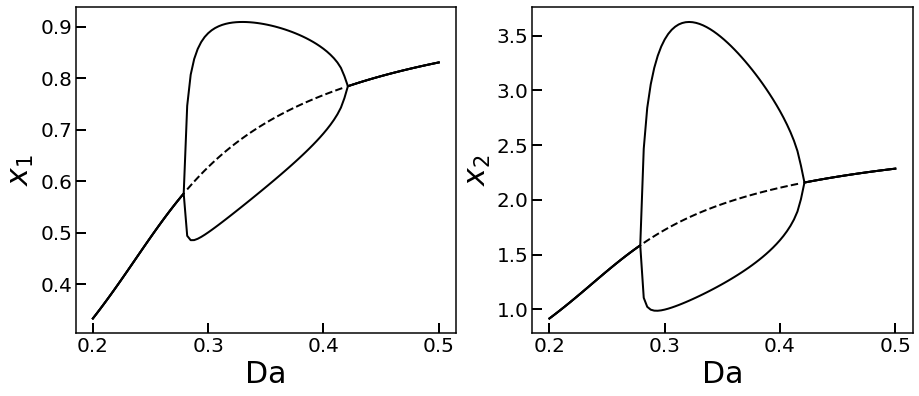

In [27]:
fig = plt.figure(figsize=(15,6))
ax = fig.add_subplot(121)
ax.plot(unstable_Da, unstable_ss[:,0], 'k--', lw=2)
ax.plot(stable_Da1, stable_ss1[:,0], 'k', lw=2)
ax.plot(stable_Da2, stable_ss2[:,0], 'k', lw=2)
ax.plot(Da_arr, x1min, 'k', lw=2)
ax.plot(Da_arr, x1max, 'k', lw=2)
ax.tick_params(axis='both', which='major', labelsize=20, direction='in', length=10, width=2)
ax.set_ylabel('$x_1$', fontsize=30)
ax.set_xlabel('Da', fontsize=30)
[x.set_linewidth(1.5) for x in ax.spines.values()]

ax = fig.add_subplot(122)
ax.plot(unstable_Da, unstable_ss[:,1], 'k--', lw=2)
ax.plot(stable_Da1, stable_ss1[:,1], 'k', lw=2)
ax.plot(stable_Da2, stable_ss2[:,1], 'k', lw=2)
ax.plot(Da_arr, x2min, 'k', lw=2)
ax.plot(Da_arr, x2max, 'k', lw=2)
ax.set_ylabel('$x_2$', fontsize=30)
ax.set_xlabel('Da', fontsize=30)
ax.tick_params(axis='both', which='major', labelsize=20, direction='in', length=10, width=2)
[x.set_linewidth(1.5) for x in ax.spines.values()]
